In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.timeseries import LombScargle
import pandas as pd
import scipy.io as sp
import emcee

# S+Leaf multi GP 

In [2]:
from spleaf import cov, term
from scipy.optimize import fmin_l_bfgs_b
import re

In [3]:
realis = 2
use_file = f"serie_res_bt_G2_1000_4m_NOISE0.09_OGS_MAG_M1_real{realis}.sav"
data = sp.readsav(use_file)

arr_len = len(data['tt'])
tt = data['tt']
rv = data['rv']
rhk = data['ca']
erv = np.zeros(len(rhk))+0.09
rhk_err = np.zeros(len(rhk))+5e-4

rv_mean = np.mean(rv)
rv_std  = np.std(rv)
rv_norm = (rv - rv_mean) / rv_std

# RHK normalization
rhk_mean = np.mean(rhk)
rhk_std  = np.std(rhk)
rhk_norm = (rhk - rhk_mean) / rhk_std

# ERROR normalization using SAME scaling as parent data
erv_norm     = erv / rv_std
rhk_err_norm = rhk_err / rhk_std

T = [tt,tt]
Y = [rv_norm,rhk_norm]
Yerr = [erv_norm,rhk_err_norm]

In [4]:
t_full, y_full, yerr_full, series_index = cov.merge_series(T,Y,Yerr)

In [5]:
sig0 = np.var(y_full)          
period0 = 21.0
Q0 = 1.0

stds = [np.std(y) for y in Y]
series = ['rv','rhk']
C = cov.Cov(t_full,
  err=term.Error(yerr_full),

  rv_jit=term.InstrumentJitter(series_index[0], 0.1*stds[0]),
  rhk_jit=term.InstrumentJitter(series_index[1], 0.1*stds[1]),
  
  GP=term.MultiSeriesKernel(term.SHOKernel(sig0, period0, Q0), series_index,
  np.ones(2), np.ones(2)))

opt_param_names  = C.param[:2] + C.param[3:-1] 
# opt_param_names  = C.param[1:]

def negloglike(x, y, C):
  C.set_param(x, opt_param_names)
  nll = -C.loglike(y)
  # gradient
  grad_full = -C.loglike_grad()[1] 
  grad_opt = np.array([grad_full[C.param.index(name)] for name in opt_param_names])

  # nll_grad = -C.loglike_grad()[1][:2] 
  return (nll, grad_opt)

C.set_param([0.0], ['GP.beta_1']) 
opt_param_names

['rv_jit.sig',
 'rhk_jit.sig',
 'GP.P0',
 'GP.Q',
 'GP.alpha_0',
 'GP.alpha_1',
 'GP.beta_0']

## Optimisation

In [ ]:
bounds_list = [
    (0.0, float(stds[0])),                     # rv_jit.sig
    (0.0, float(stds[1])),                     # rhk_jit.sig
    (19.0, 30.0),                              # GP.P0 (period)
    (0.5, 10.0),                               # GP.Q (quality factor)
    (0, float(stds[0])),         # GP.alpha_0 (set lower bound to zero)
    (-float(stds[1]), float(stds[1])),         # GP.alpha_1
    (-float(stds[0]), float(stds[0])),         # GP.beta_0
    # (-float(stds[1]), float(stds[1])),         # GP.beta_1 (set to zero and don't fit)
]

x0 = C.get_param(opt_param_names)


# xbest, _, _ = fmin_l_bfgs_b(negloglike, C.get_param(opt_param_names), args=(y_full, C))
xbest, fval, info = fmin_l_bfgs_b(negloglike,
                                 x0,
                                 args=(y_full, C),
                                 bounds=bounds_list)

C.set_param(xbest, opt_param_names)
C.set_param([0.0], ['GP.beta_1'])  # set beta_1 to zero
print(xbest)

negloglike(xbest, y_full, C)


## MCMC

In [ ]:
def log_prior(theta):
    rv_jit, rhk_jit, P0, Q, alpha_0, alpha_1, beta_0 = theta
    if 0.0 < rv_jit < stds[0] and 0.0 < rhk_jit < stds[1] and 18.0 < P0 < 22.0 and 0.1 < Q < 2.0 and 0.0 < alpha_0 < 5.0 and -5.0 < alpha_1 < 5.0 and -5.0 < beta_0 < 5.0:
        return 0.0
    return -np.inf

def log_probability(theta, y, C):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + -1*negloglike(theta, y, C)[0]

x0 = C.get_param(opt_param_names)
pos = x0 + 1e-4 * np.random.randn(32, 7)
nwalkers, ndim = pos.shape

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(y_full, C)
)
sampler.run_mcmc(pos, 1000, progress=True);

/opt/anaconda3/envs/sleaf/lib/python3.10/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]


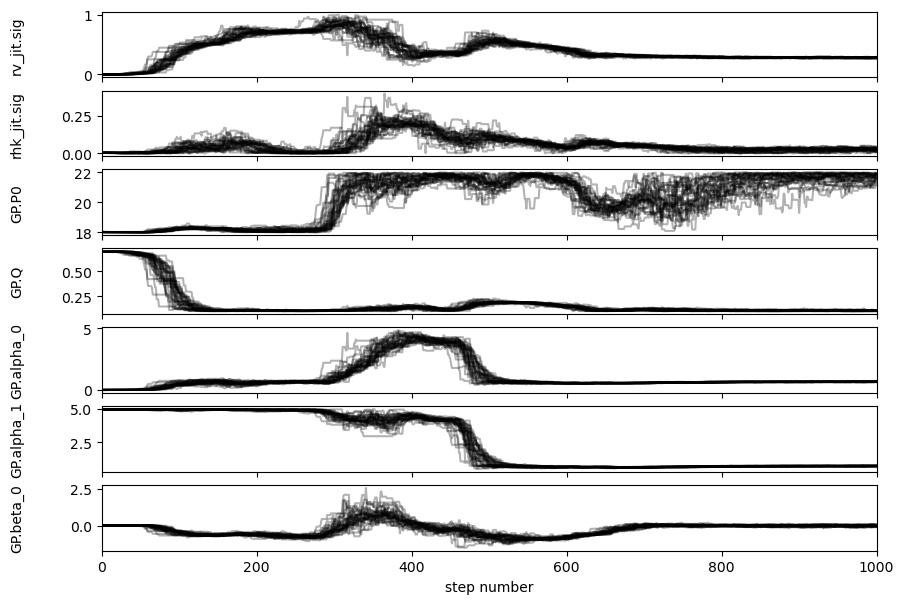

In [14]:
fig, axes = plt.subplots(7, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()
labels = opt_param_names
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

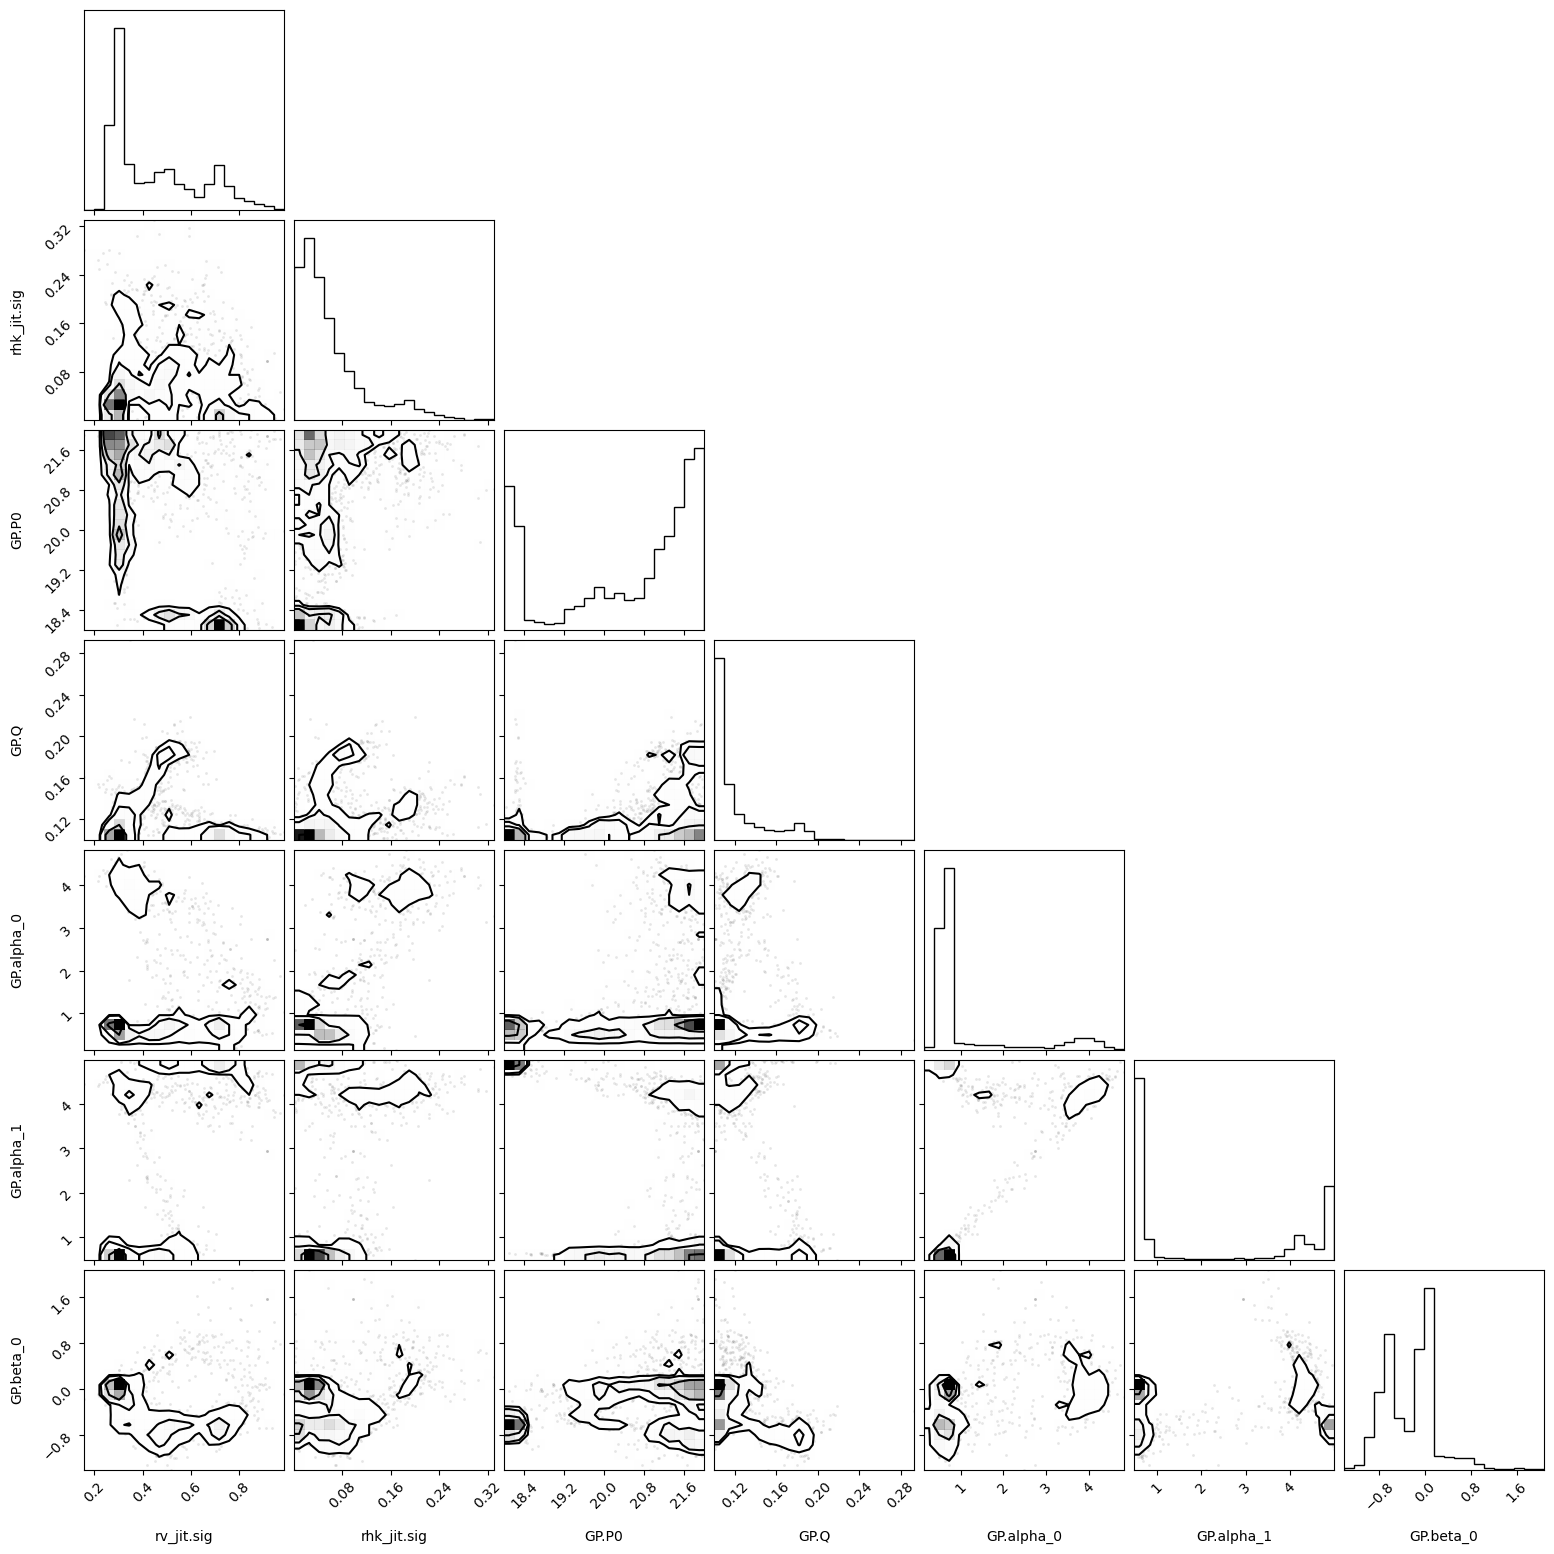

In [15]:
import corner

flat_samples = sampler.get_chain(discard=100, thin=15, flat=True)

fig = corner.corner(
    flat_samples, labels=labels
);



Plotting

In [ ]:
tsmooth = np.linspace(np.min(t_full), np.max(t_full), 1000)
_, axs = plt.subplots(2, 1, sharex=True, figsize=(15, 10))


for k in range(2):
  # Predict time series k
  C.kernel['GP'].set_conditional_coef(series_id=k)
  mu, var = C.conditional(y_full, tsmooth, calc_cov='diag')
  mu_res, _ = C.conditional(y_full, T[k], calc_cov='diag')
  if k == 0:
    res_rv = Y[k] - mu_res
  else:
    res_rhk = Y[k] - mu_res
  # Plot
  
  ax = axs[k]
  ax.errorbar(T[k], Y[k], Yerr[k], fmt='.', color='k', label='meas.')
  ax.fill_between(tsmooth,
    mu - np.sqrt(var),
    mu + np.sqrt(var),
    color='g',
    alpha=0.5)
  ax.plot(tsmooth, mu, 'g', label='predict.')
  ax.set_ylabel(f'$y_{k}$')
ax.set_xlabel('$t$')
axs[0].legend()

plt.show()

In [ ]:
plt.figure()
for k in range(2):
  if k == 0:
    plt.plot(tt, res_rv, ".",label='RV Residuals')
  else:
    plt.plot(tt, res_rhk, ".",label='RHK Residuals')
plt.legend()

# Residuals comparison between pyaneti, tinygp, suzanne's model, and s+leaf

In [ ]:
file = f"pyaneti_test_{realis}_out/pyaneti_test_{realis}_rv_residuals.dat"

data_2 = np.loadtxt(f'test_{realis}.dat', dtype=str)
data_2_time = data_2[:, 0].astype(float)[:1000]  

tinygp_res_2 = np.load(f"G2_nopl_2DGP_whole_M1_real{realis}_FFPer_resid.npy")
ffp_res_2 = np.load(f"G2_nopl_FFPer_LS_S10_M1_real{realis}_FFPer_resid.npy")
my_res_2 = pd.read_csv(file, sep=r'\s+', usecols=[1]).values[:1000].flatten()*1000


frequency_me, power_me = LombScargle(data_2_time, my_res_2).autopower()
frequency_tinygp, power_tinygp = LombScargle(data_2_time, tinygp_res_2).autopower()
frequency_ffp, power_ffp = LombScargle(data_2_time, ffp_res_2).autopower()
frequency_spleaf, power_spleaf = LombScargle(data_2_time, res_rv).autopower()

plt.figure()
plt.plot(data_2_time, tinygp_res_2, ".",label='tinygp Residuals')
plt.plot(data_2_time, ffp_res_2, ".",label='ffp Residuals')
plt.plot(data_2_time,my_res_2, ".",label='pyaneti Residuals')
plt.plot(tt,res_rv, ".",label='spleaf Residuals')
plt.legend()
plt.xlim(700, 3000)
plt.ylabel("Residuals (m/s)")

plt.figure()
plt.plot(frequency_tinygp, power_tinygp,label="tinygp")
plt.plot(frequency_ffp, power_ffp,label="ffp")
plt.plot(frequency_me, power_me, alpha = 0.5,label="pyaneti")
plt.plot(frequency_spleaf, power_spleaf,label="spleaf")


plt.xlabel("Frequency")
plt.ylabel("Power")
plt.semilogx()
plt.legend()

